### House Prices EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ml_pipeline.regression.pipeline import RegressionPipeline
from ml_pipeline.regression.config import regression_config as config

def boxplot(results: list, labels: list | None = None):
    data = []

    for item in results:
        data.append([x["score"] for x in item["fold_data"]])

    plt.boxplot(data, tick_labels=labels)
    plt.show()

Полный пайплайн

neg_root_mean_squared_error используется, потому что пайплайн выбирает наибольшую метрику, а не наименьшую (так как пайплайн изначально был построен под accuracy классификации)

In [ ]:
pipeline = RegressionPipeline()

In [ ]:
pipeline.run()

{'model': 'dummy'}
Шаг (0): dummy с {'strategy': 'mean'}
Фолд 1/5 neg_root_mean_squared_error: -0.4332
Фолд 2/5 neg_root_mean_squared_error: -0.3958
Фолд 3/5 neg_root_mean_squared_error: -0.3754
Фолд 4/5 neg_root_mean_squared_error: -0.4210
Фолд 5/5 neg_root_mean_squared_error: -0.3685
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.3988, std: 0.0251

{'model': 'linear', 'params': {'alpha': 1.0}}
Шаг (1): linear с {'alpha': 1.0, 'solver': 'auto', 'max_iter': 500}
Фолд 1/5 neg_root_mean_squared_error: -0.0935
Фолд 2/5 neg_root_mean_squared_error: -0.0924
Фолд 3/5 neg_root_mean_squared_error: -0.0861
Фолд 4/5 neg_root_mean_squared_error: -0.0860
Фолд 5/5 neg_root_mean_squared_error: -0.0793
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.0875, std: 0.0051

{'model': 'knn', 'params': {'n_neighbors': 3}}
Шаг (2): knn с {'n_neighbors': 3}
Фолд 1/5 neg_root_mean_squared_error: -0.0116
Фолд 2/5 neg_root_mean_squared_error: -0.0081
Фолд 3/5 neg_root_mean_squared_error: -0.0050
Фолд

ValueError: 'Sex' is not in list

### Линейная модель

Посмотрим, как alpha l2 регуляризации влияет на метрику

Без alpha метрика улетает

In [3]:
config_alphas = config.copy()

to_train = []

for i in range(0, 10):
    to_train.append(
        {
            "model": "linear",
            "params": {"alpha": i, "max_iter": 2000},
        }
    )

config_alphas.experiment.to_train = to_train
# config_alphas.experiment.prediction.fold_strategy = "vote"

linear_alphas_pipeline = RegressionPipeline(config_alphas)

linear_alphas_pipeline.run()

{'model': 'linear', 'params': {'alpha': 0, 'max_iter': 2000}}
Шаг (0): linear с {'alpha': 0, 'solver': 'auto', 'max_iter': 2000}
Фолд 1/5 neg_root_mean_squared_error: -24083206.5771
Фолд 2/5 neg_root_mean_squared_error: -16203062.7810
Фолд 3/5 neg_root_mean_squared_error: -18097214.7666
Фолд 4/5 neg_root_mean_squared_error: -24694312.4939
Фолд 5/5 neg_root_mean_squared_error: -23231845.6915
-> Лучший фолд: 2, CV neg_root_mean_squared_error: -21261928.4620, std: 3441772.1885

{'model': 'linear', 'params': {'alpha': 1, 'max_iter': 2000}}
Шаг (1): linear с {'alpha': 1, 'solver': 'auto', 'max_iter': 2000}
Фолд 1/5 neg_root_mean_squared_error: -0.0935
Фолд 2/5 neg_root_mean_squared_error: -0.0923
Фолд 3/5 neg_root_mean_squared_error: -0.0858
Фолд 4/5 neg_root_mean_squared_error: -0.0861
Фолд 5/5 neg_root_mean_squared_error: -0.0792
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.0874, std: 0.0052

{'model': 'linear', 'params': {'alpha': 2, 'max_iter': 2000}}
Шаг (2): linear с {'alpha'

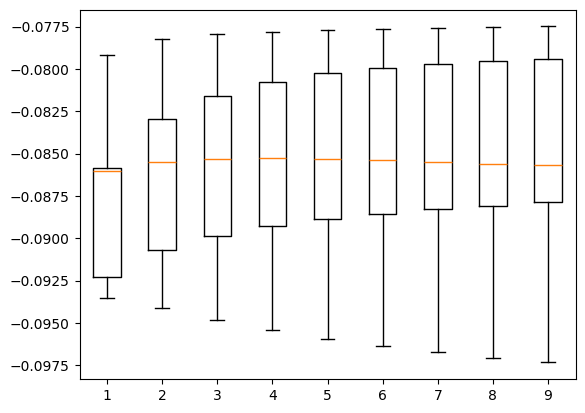

In [ ]:
# не показывать результаты без alpha, чтобы не сбивать масштаб
boxplot(linear_alphas_pipeline.results[1:])

### Бустинг

#### CatBoost

In [17]:
config_cat = config.copy()

to_train = []

iteration_counts = [*[i * 100 for i in range(1, 8)], 1000, 2000]

for ic in iteration_counts:
    to_train.append(
        {
            "model": "catboost",
            "params": {"iterations": ic},
        }
    )


config_cat.experiment.to_train = to_train

pipeline_cat = RegressionPipeline(config_cat)

pipeline_cat.run()

{'model': 'catboost', 'params': {'iterations': 100}}
Шаг (0): catboost с {'iterations': 100, 'depth': 6, 'cat_features': ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'], 'learning_rate': 0.1, 'random_state': 42, 'verbose': 0}
Series([], dtype: int64)
Фолд 1/5 neg_root_mean_squared_error: -0.0333
Series([], dtype: int64)
Фолд 2/5 neg_root_mean_squared_error: -0.0281
Series([], dtype: int64)
Фолд 3/5 neg_root_mean_squared_error: -0.0259
Series([], dtype: int64)
Фолд

KeyboardInterrupt: 

In [ ]:
df[categorical_feats].isna().sum()

np.False_